## 1. Import Libraries
Import core libraries required for data handling (pandas, numpy) and visualization (matplotlib).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Basic Data Audit
This cell checks dataset shape, column names, data types, missing values, and target balance.

In [2]:
df = pd.read_csv("../train.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,1


## 3. Basic Data Audit
Inspect dataset structure: shape, column names, data types, missing values, and target distribution to assess class imbalance.

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget counts:")
print(df["target"].value_counts())

print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))

Shape: (736, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
target        int64
dtype: object

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     50
chol         27
fbs          68
restecg       0
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
target        0
dtype: int64

Target counts:
target
1    407
0    329
Name: count, dtype: int64

Target proportions:
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64


## 4. Target Distribution Visualization
Visualize the distribution of the target variable (heart disease vs no disease) to support evaluation metric selection.

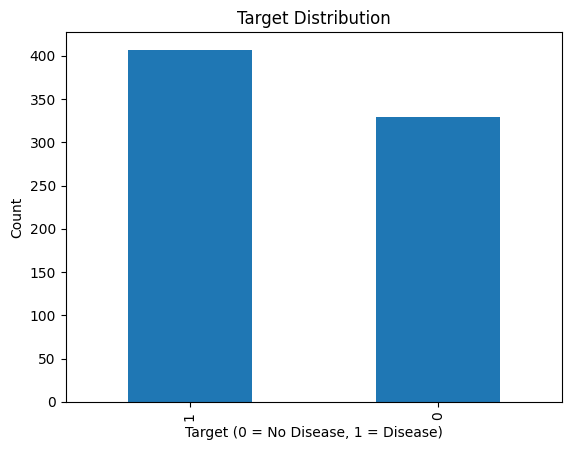

In [4]:
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

## 5. Institutional (Dataset) Analysis
Analyze distribution of patients and disease prevalence across contributing hospitals using the `dataset` column.

dataset
Cleveland        249
Hungary          229
VA Long Beach    163
Switzerland       95
Name: count, dtype: int64
target           0    1
dataset                
Cleveland      136  113
Hungary        145   84
Switzerland      7   88
VA Long Beach   41  122


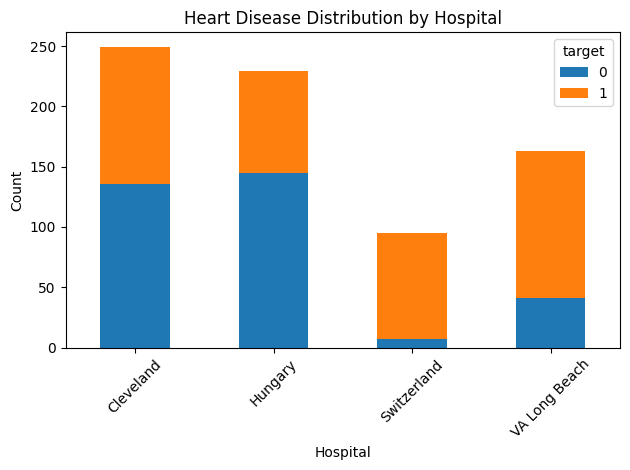

In [5]:
print(df["dataset"].value_counts())

site_target = pd.crosstab(df["dataset"], df["target"])
print(site_target)

site_target.plot(kind="bar", stacked=True)
plt.title("Heart Disease Distribution by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Data Quality Check (Invalid Values)
Identify biologically implausible values (e.g., cholesterol = 0) which indicate missing or corrupted data.

In [6]:
print("chol == 0:", (df["chol"] == 0).sum())
print("trestbps == 0:", (df["trestbps"] == 0).sum())

if "thalch" in df.columns:
    print("thalch == 0:", (df["thalch"] == 0).sum())

chol == 0: 132
trestbps == 0: 0
thalch == 0: 0


## 7. Replace Invalid Values
Convert invalid placeholder values (e.g., zeros) into proper missing values (NaN) for correct downstream handling.

In [7]:
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)

if "thalch" in df.columns:
    df["thalch"] = df["thalch"].replace(0, np.nan)

## 8. Feature Type Identification
Separate numerical and categorical features and exclude non-predictive columns (`id`, `target`) from preprocessing groups.

In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

for col in ["id", "target"]:
    if col in num_cols:
        num_cols.remove(col)
    if col in cat_cols:
        cat_cols.remove(col)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## 9. Missing values before modeling

Feature matrix still contains NaN after invalid values were recoded. Counts below are **before** imputation. The sklearn pipeline in the next sections imputes using **training data only** (and again inside each CV fold), avoiding leakage from global medians/modes.

In [9]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     50
chol        159
fbs          68
restecg       0
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
target        0
dtype: int64


## 10. Stratified train/test split

Drop `id`, separate features `X` and target `y`, cast categoricals to **object** (avoids pandas `StringDtype` / `pd.NA`, which can break sklearn imputers), then **stratified** `train_test_split` so train and test match the target prevalence (~55% positive).

In [10]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

X = df.drop(columns=["target"]).copy()
y = df["target"]

# object dtype avoids pd.NA from StringDtype, which breaks sklearn's SimpleImputer
for col in cat_cols:
    X[col] = X[col].astype(object)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (588, 14) Test: (148, 14)


## 11. Preprocessing pipeline and logistic regression

`ColumnTransformer`: **median** imputation + **standard scaling** on numeric columns; **most frequent** imputation + **one-hot** encoding (`drop="first"`, `handle_unknown="ignore"`) on categoricals—aligned with the earlier pandas `get_dummies(..., drop_first=True)` idea, but **fit on training data only**.

**Logistic regression** is the standard linear model for a binary `target` (linear in log-odds). Each pipeline step uses a **clone** of the preprocessor so logistic and OLS estimators do not share one fitted transformer.

In [11]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ]
)

clf_pipeline = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        (
            "model",
            LogisticRegression(max_iter=2000, random_state=42),
        ),
    ]
)

clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7972972972972973
F1: 0.8235294117647058
ROC-AUC: 0.8880266075388025

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.76        66
           1       0.80      0.85      0.82        82

    accuracy                           0.80       148
   macro avg       0.80      0.79      0.79       148
weighted avg       0.80      0.80      0.80       148

Confusion matrix:
 [[48 18]
 [12 70]]


## 12. Stratified cross-validation

Five-fold CV **refits the full pipeline** on each training fold so imputers and encoders never see validation rows during training. Report mean ± std for F1 and ROC-AUC.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_pipeline = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        (
            "model",
            LogisticRegression(max_iter=2000, random_state=42),
        ),
    ]
)
cv_scores = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=["f1", "roc_auc"],
    n_jobs=-1,
)

print(
    "F1:       mean = {:.3f}, std = {:.3f}".format(
        cv_scores["test_f1"].mean(),
        cv_scores["test_f1"].std(),
    )
)
print(
    "ROC-AUC:  mean = {:.3f}, std = {:.3f}".format(
        cv_scores["test_roc_auc"].mean(),
        cv_scores["test_roc_auc"].std(),
    )
)

F1:       mean = 0.849, std = 0.012
ROC-AUC:  mean = 0.901, std = 0.013


## 13. OLS (`LinearRegression`) comparison

Ordinary least squares on a 0/1 target is a **linear probability model**. Predictions need not lie in $[0, 1]$. This section is **illustrative**; **logistic regression** above is the recommended linear baseline for binary classification.

In [13]:
ols_pipeline = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        ("model", LinearRegression()),
    ]
)
ols_pipeline.fit(X_train, y_train)

y_ols_pred = ols_pipeline.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_ols_pred))
print("R2:", r2_score(y_test, y_ols_pred))

y_ols_class = (y_ols_pred >= 0.5).astype(int)
print("Accuracy (threshold 0.5):", accuracy_score(y_test, y_ols_class))
print("F1 (threshold 0.5):", f1_score(y_test, y_ols_class))

MSE: 0.13918000507307304
R2: 0.43669644657786544
Accuracy (threshold 0.5): 0.8040540540540541
F1 (threshold 0.5): 0.8284023668639053


## 14. Logistic regression coefficients (largest magnitude)

Numeric inputs are **scaled** in the pipeline; one-hot columns are 0/1. Coefficient sizes are **most comparable within** the scaled numeric block versus binary dummies.

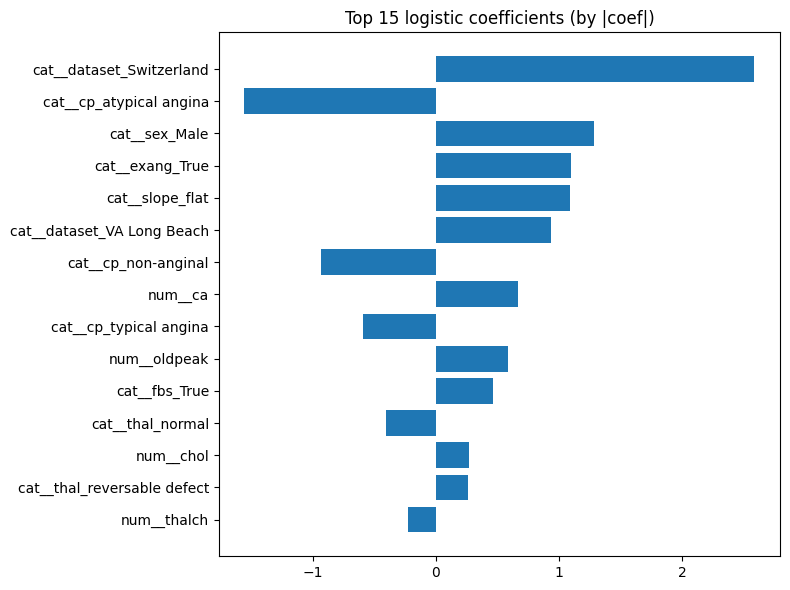

,feature,coef
0,cat__dataset_Switzerland,2.589859
1,cat__cp_atypical angina,-1.554302
2,cat__sex_Male,1.285463
3,cat__exang_True,1.095406
4,cat__slope_flat,1.088882
5,cat__dataset_VA Long Beach,0.938512
6,cat__cp_non-anginal,-0.932407
7,num__ca,0.666951
8,cat__cp_typical angina,-0.593343
9,num__oldpeak,0.585224


In [14]:
log_reg = clf_pipeline.named_steps["model"]
feature_names = clf_pipeline.named_steps["prep"].get_feature_names_out()
coefs = log_reg.coef_.ravel()
order = np.argsort(np.abs(coefs))[::-1][:15]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(feature_names)[order][::-1], coefs[order][::-1])
ax.set_title("Top 15 logistic coefficients (by |coef|)")
plt.tight_layout()
plt.show()

pd.DataFrame({"feature": feature_names, "coef": coefs}).iloc[order].reset_index(drop=True)

## Summary

1. Audited the data, target balance, and site mix; recoded invalid zeros to missing.
2. Built **leakage-safe** learning: stratified train/test split, then **median / most-frequent imputation and encoding fit only on training** (and refit per fold in CV).
3. **Logistic regression** (primary): hold-out and **5-fold stratified CV** metrics (F1, ROC-AUC), plus report, confusion matrix, and coefficient snapshot.
4. **Linear regression (OLS)** on the same split for comparison (MSE, R², thresholded accuracy/F1)—**not** the preferred model for a binary outcome.

For challenge submission, reuse the same `ColumnTransformer` + `LogisticRegression` `Pipeline` trained on the full training CSV with the same cleaning rules applied to `test.csv`.